# Modeling Pipeline for Vishing Detection
This notebook trains and evaluates multiple algorithms (Logistic Regression, Random Forest, XGBoost, and Neural Networks) iterating over the different datasets generated in the data balancing process (SMOTE, Random Oversampling, Borderline SMOTE and SMOTE + Undersampling).

## 1. Setup and Hold-out Extraction (Test Set)
To evaluate fairly, we need a completely untouched test set (unbalanced). We take the original dataset and extract 20% for evaluation.

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load original data to obtain a realistic Test Set
df_raw = pd.read_csv('raw_data/dataset_sintetico_biocatch_vishing.csv')

# Exclude features that cause data leakage according to the EDA
cols_to_drop = ['session_id', 'customer_id', 'session_timestamp', 'biocatch_risk_score', 'biocatch_genuine_score', 
                'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'days_to_claim', 'claim_category','os_type','app_version','device_type']

for col in ['screens_visited', 'unusual_screen_visits']:
    if col in df_raw.columns:
        df_raw.drop(columns=[col], inplace=True)

df_raw = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])

X_orig = df_raw.drop(columns=['is_vishing'])
y_orig = df_raw['is_vishing']

_, X_test, _, y_test = train_test_split(X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig)

scaler = StandardScaler()

## 2. Multi-model Pipeline Definition
We will iterate through each folder and file inside data/.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=6, learning_rate=0.1, random_state=42),
    'Deep Learning (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42)
}

data_paths = glob.glob('data/**/*.csv', recursive=True)
results = []

print(f"Detected {len(data_paths)} balanced datasets for evaluation.")

Detected 12 balanced datasets for evaluation.


In [5]:
for path in data_paths:
    technique = Path(path).parent.name
    ratio = Path(path).stem
    
    print(f"\n--- Evaluating {technique} at {ratio}% ---")
    
    df_train = pd.read_csv(path)
    df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], errors='ignore')
    
    for col in ['screens_visited', 'unusual_screen_visits']:
        if col in df_train.columns:
            df_train.drop(columns=[col], inplace=True)
            
    X_train = df_train.drop(columns=['is_vishing'])
    y_train = df_train['is_vishing']
    
    X_train = X_train[X_test.columns]
    
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for model_name, model in models.items():
        if model_name in ['Logistic Regression', 'Deep Learning (MLP)']:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test
            
        model.fit(X_tr, y_train)
        
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred
        
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        
        results.append({
            'Technique': technique,
            'Ratio_%': ratio,
            'Model': model_name,
            'Recall': recall,
            'Precision': precision,
            'F1': f1,
            'ROC_AUC': roc_auc,
            'PR_AUC': pr_auc
        })
        
print("\nMassive iteration pipeline finished successfully!")


--- Evaluating borderline_smote at 10% ---

--- Evaluating borderline_smote at 20% ---

--- Evaluating borderline_smote at 25% ---

--- Evaluating random_oversampling at 10% ---

--- Evaluating random_oversampling at 20% ---

--- Evaluating random_oversampling at 25% ---

--- Evaluating smote at 10% ---

--- Evaluating smote at 20% ---

--- Evaluating smote at 25% ---

--- Evaluating smote_undersampling at 10% ---

--- Evaluating smote_undersampling at 20% ---

--- Evaluating smote_undersampling at 25% ---

Massive iteration pipeline finished successfully!


## 3. Results Analysis and Identification of the Best Strategy

In [11]:
df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(by='PR_AUC', ascending=False)
display(df_results_sorted.head(15).style.background_gradient(cmap='viridis', subset=['Recall', 'PR_AUC', 'ROC_AUC']))

,Technique,Ratio_%,Model,Recall,Precision,F1,ROC_AUC,PR_AUC
13,random_oversampling,10,Random Forest,0.010000,1.000000,0.019802,1.000000,1.000000
29,smote,20,Random Forest,0.002000,1.000000,0.003992,1.000000,1.000000
21,random_oversampling,25,Random Forest,0.104000,1.000000,0.188406,1.000000,1.000000
17,random_oversampling,20,Random Forest,0.018000,1.000000,0.035363,1.000000,1.000000
1,borderline_smote,10,Random Forest,0.000000,0.000000,0.000000,1.000000,0.999992
5,borderline_smote,20,Random Forest,0.002000,1.000000,0.003992,1.000000,0.999992
25,smote,10,Random Forest,0.002000,1.000000,0.003992,0.999999,0.999984
9,borderline_smote,25,Random Forest,0.008000,1.000000,0.015873,0.999999,0.999980
41,smote_undersampling,20,Random Forest,0.000000,0.000000,0.000000,0.999998,0.999964
37,smote_undersampling,10,Random Forest,0.000000,0.000000,0.000000,0.999994,0.999889


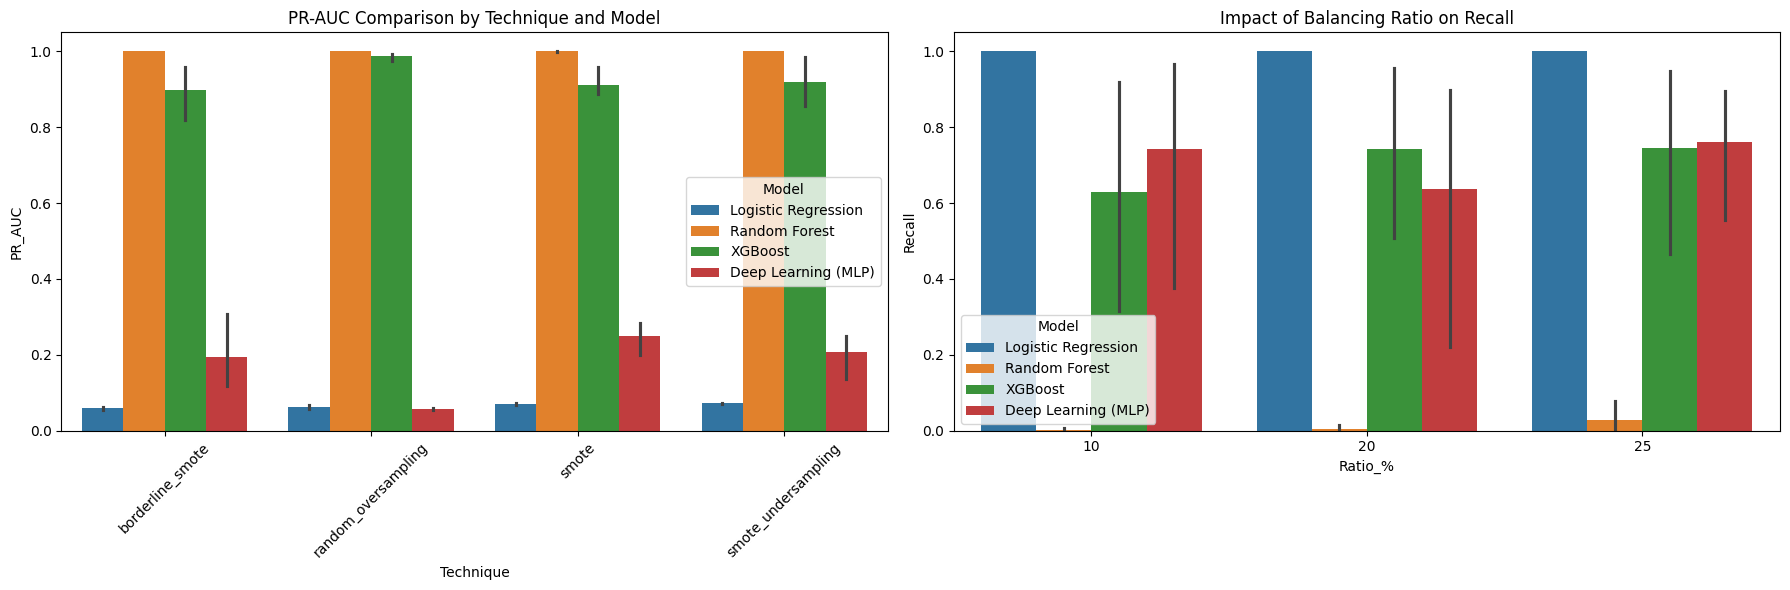

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_results, x='Technique', y='PR_AUC', hue='Model', ax=ax1)
ax1.set_title('PR-AUC Comparison by Technique and Model')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sns.barplot(data=df_results, x='Ratio_%', y='Recall', hue='Model', ax=ax2)
ax2.set_title('Impact of Balancing Ratio on Recall')

plt.tight_layout()
plt.show()

## 4. Confusion Matrix — Best Model: XGBoost with SMOTE-Undersampling at 10%

We retrain the winning model on the balanced dataset `smote_undersampling/10` and evaluate it on the original hold-out set to get a detailed view of the errors (False Negatives and False Positives).

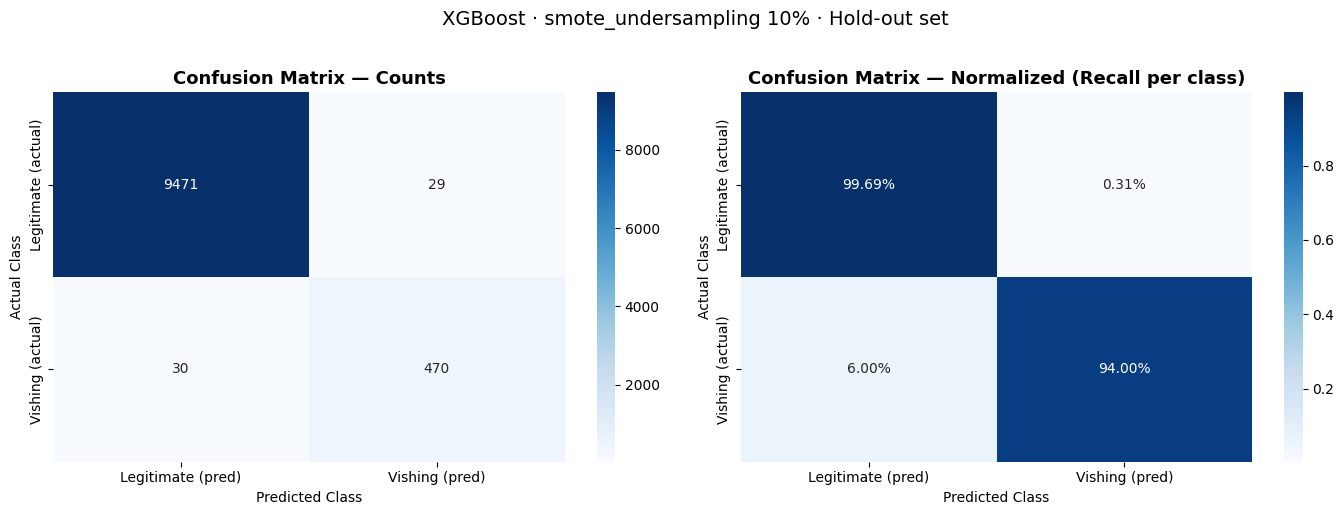


  True Negatives  (TN) :   9471  — Legitimate correctly identified
  False Positives (FP) :     29  — Legitimate flagged as Vishing
  False Negatives (FN) :     30  — Vishing not detected  ← critical risk
  True Positives  (TP) :    470  — Vishing correctly detected
  Recall    (Sensitivity)   : 0.9400
  Precision                 : 0.9419
  F1-Score                  : 0.9409
  ROC-AUC                   : 0.9988
  PR-AUC                    : 0.9848


In [14]:
# --- Best model: XGBoost | smote_undersampling | 10% ---
best_path = 'data\\balanced\\original\\smote_undersampling\\10.csv'

df_best = pd.read_csv(best_path)
df_best = df_best.drop(columns=[c for c in cols_to_drop if c in df_best.columns], errors='ignore')
for col in ['screens_visited', 'unusual_screen_visits']:
    if col in df_best.columns:
        df_best.drop(columns=[col], inplace=True)

X_best = df_best.drop(columns=['is_vishing'])[X_test.columns]
y_best = df_best['is_vishing']

best_model = XGBClassifier(
    use_label_encoder=False, eval_metric='logloss',
    max_depth=6, learning_rate=0.1, random_state=42
)
best_model.fit(X_best, y_best)

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix with counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Legitimate (pred)', 'Vishing (pred)'],
    yticklabels=['Legitimate (actual)', 'Vishing (actual)']
)
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Class')
axes[0].set_xlabel('Predicted Class')

# Normalized confusion matrix (per row = recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
    xticklabels=['Legitimate (pred)', 'Vishing (pred)'],
    yticklabels=['Legitimate (actual)', 'Vishing (actual)']
)
axes[1].set_title('Confusion Matrix — Normalized (Recall per class)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Class')
axes[1].set_xlabel('Predicted Class')

plt.suptitle('XGBoost · smote_undersampling 10% · Hold-out set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"  True Negatives  (TN) : {tn:>6}  — Legitimate correctly identified")
print(f"  False Positives (FP) : {fp:>6}  — Legitimate flagged as Vishing")
print(f"  False Negatives (FN) : {fn:>6}  — Vishing not detected  ← critical risk")
print(f"  True Positives  (TP) : {tp:>6}  — Vishing correctly detected")
print(f"{'='*50}")
print(f"  Recall    (Sensitivity)   : {tp/(tp+fn):.4f}")
print(f"  Precision                 : {tp/(tp+fp):.4f}")
print(f"  F1-Score                  : {2*tp/(2*tp+fp+fn):.4f}")
print(f"  ROC-AUC                   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  PR-AUC                    : {average_precision_score(y_test, y_prob_best):.4f}")
print(f"{'='*50}")